**<h1>AHJ Database: California Built Environment Personnel Mapping 2025**
#### Analysis 2.v4 =  Analysis 2 (filtered GCC data) + Geomap
<i>Any question regarding the notebook, please contact Robert Ford<br>
    Last Updated: 06/30/2025</i>
* AHJ Data: City and County level data sourced from Government Compensation California (GCC)
* Geo Data: Various open source databases including state and federal - ranging from census, ArcGIS, and other open sources
* Started development on 06/25/2025
* Finished Iteration on -06/30/2025-

In [162]:
# Run once for pip installs and upgrades
#%pip install --upgrade pip


In [ ]:
# Import and load libs and packages
import pandas as pd
import seaborn as sns
import re
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import stopwords
from rapidfuzz import process, fuzz

# Download NLTK stopwords
nltk.download('stopwords')


In [164]:
# Load base dataset here
df = pd.read_excel("2023_City.xlsx")

# Split into training (30%) and test (70%)
train_df = df.sample(frac=0.3, random_state=42)
test_df = df.drop(train_df.index)

In [165]:
# Keywords to KEEP
keep_dept_keywords = [
    "Planning", "Community Development", "Building Department", "Code Compliance",
    "Public Works", "Streets", "Engineering", "Construction", "Zoning"
]

keep_position_keywords = [
    "Construction", "Building", "HVAC", "Plans Inspector", "Zoning Investigator",
    "Architect", "Permit Technician", "Safety Inspector", "Planner", "Code Enforcer",
    "Plan Check Coordinator", "Licensing Specialist", "Community Development Technician"
]

# Keywords to FILTER OUT
filter_dept_keywords = [
    "Administration", "Communications", "Animal", "Finance", "Community Services",
    "Municipal Power", "Base Reuse", "City Attorney", "City Clerk", "Council", "Fire",
    "Human Resources", "Library", "IT", "Police", "Recreation", "Government Services",
    "Facilities", "Water", "Power", "Airport", "Health", "Zero Waste", "Sewer",
    "Equipment", "Transfer Station", "Janitor", "Landscaping", "Utilities", "Business",
    "Transit", "Nutrition", "Aging", "Adult", "Youth", "Homeless", "Athletics", "Law",
    "Attorney", "Management","Public Works - Sanitation","Public Works - Street Services",
    "Public Works - Maint Svcs","Streets","Public Works-Operations","Public Works - Parks And Landscape ",
    "Public Works - Streets","Public Works-Corporate Yard","Public Works - Maintenance",
    "Public Works - Parks","Public Works Operations","Public Works - Refuse","Public Works/Solid Waste",
    "Public Works - Solid Waste","Public Works - Wastewater","Public Works/Street Maintenance",
    "War Memorial","Public Works - Right Of Way","Public Works - Utility Services", "Street Maintenance",
    "Public Works Parks","Grounds Maintenance","Public Works Yard",
    
]

filter_position_keywords = [
    "Motor Sweeper Operator","Public Works Ranger","Park Ranger","Administrative Assistant","Fitness instructor",
    "Administrative Intern","Equipment Operator","Crossing Guard","Park Lead","Plumber","Mechanic","Gardener",
    "Temporary","Chemist","Seasonal Aide","Plant Operator","Foreman Water","Solid Resources","Parks","Asphalt Worker",
    "Business Analyst","Human Resources","Parking","Facilities","Golf","Downtown","Stationary","Groundskeeper"
    "Laboratory Technician", "Building & Grounds Patrol Officer", "Patrol Officer", "Youth Job Corps Program Participant",
    "School Guard","Tree Trimmer", "Transit Coach Operator", "Street Inspector","Utility Worker","Custodial",
    "Office Specialist","Street Services","Maintenance","Accountant","City Worker","Sanitation","Graffiti"
    "Maintenance Supervisor","Wastewater Treatment Operator","Wastewater Treatment Mechanic","Office Assistant",
    "Recreational Leader", "Librarian", "Admin", "Clerk","Wastewater System Operator","Water Foreman",
    "Wastewater Conveyance Operator","Management Assistant","Street Maintenance Worker","Maintenance Aide",
    "Lot Operator","Public Works Maintenance Worker","Maintenance Worker","Project Assistant","Project Manager",
    "Tree Surgeon","Intern","Truck Driver","Solid Waste Equipment Operator","Refuse Operator","Refuse Collection Supervisor",
    "Secretary", "Parking Officer", "Police", "Firefighter", "Treasurer", "Employment Worker",
    "Lifeguard", "Animal", "Recycling","Management Analyst", "Sewer", "Finance", "HR", "IT", "Parks & Rec",
    "Health", "EMT", "Custodian","Maintenance Worker", "Equipment Mechanic", "Aquatics", "Traffic",
    "Community Service", "Veterinary", "Senior Citizen", "Pool", "Utilities", "Audio","Irrigation Specialist",
    "Communications", "Mayor", "Attendant", "Vocational Worker", "Messenger Clerk","Staff Assistant",
    "Customer Service", "Truck Operator", "Sanitation", "Painter","Water Utility Worker","Arborist"
    "Laborer", "Program Assistant","Staff Specialist","Refuse","Department Assistant","Landscape"
]


In [166]:
# Helper function to match keywords
def keyword_match(text, keywords):
    if pd.isna(text):
        return False
    return any(re.search(rf'\b{re.escape(k)}\b', str(text), re.IGNORECASE) for k in keywords)

# Label rows for training
def label_row(row):
    keep_dept = keyword_match(row['DepartmentOrSubdivision'], keep_dept_keywords)
    keep_pos = keyword_match(row['Position'], keep_position_keywords)
    filter_dept = keyword_match(row['DepartmentOrSubdivision'], filter_dept_keywords)
    filter_pos = keyword_match(row['Position'], filter_position_keywords)
    return int((keep_dept or keep_pos) and not (filter_dept or filter_pos))


In [ ]:
# Apply labeling
train_df["label"] = train_df.apply(label_row, axis=1)

# Combine text for model training
train_df["combined_text"] = train_df["DepartmentOrSubdivision"].fillna('') + " " + train_df["Position"].fillna('')

# Show label distribution
train_df["label"].value_counts()


In [168]:
# Feature and Target Preparation

X = train_df["combined_text"]
y = train_df["label"]


In [169]:
# Create pipeline with TF-IDF + Random Forest
model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words=stopwords.words('english'), max_features=1000)),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
# Train model
model.fit(X, y)


,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [ ]:
# Combine text columns
test_df["combined_text"] = test_df["DepartmentOrSubdivision"].fillna('') + " " + test_df["Position"].fillna('')

# Predict using the trained model
test_df["predicted_label"] = model.predict(test_df["combined_text"])

# Filter the results
filtered_test_df = test_df[test_df["predicted_label"] == 1]
filtered_train_df = train_df[train_df["label"] == 1]
filtered_df = pd.concat([filtered_train_df, filtered_test_df], ignore_index=True)


# Display summary
print(f"Filtered rows: {len(filtered_df)} / {len(df)}")
filtered_df.head()



In [171]:
# Visual Checks of headers for personnel data and geodata 
#print(ca_personnel.head())
#print(ca_personnel.columns)


In [172]:
# Cleaning function
def clean_name(name):
    name = str(name).strip().lower()
    return name.title() if name else ''

# Clean columns for joining
filtered_df['clean_city_name'] = filtered_df['EmployerName'].apply(clean_name)
filtered_df['clean_county_name'] = filtered_df['EmployerCounty'].apply(clean_name)


In [173]:
# Filters: Empty if not needed

# Specify the city to exclude
excluded_cities = ["Los Angeles"]
# Specify the county to exclude
excluded_counties = ["Los Angeles"]


In [174]:
# Aggregate and filter 
agg_city_counts = filtered_df.groupby('clean_city_name').size().reset_index(name='personnel_count_city')
agg_county_counts = filtered_df.groupby('clean_county_name').size().reset_index(name='personnel_count_county')

filtered_city = filtered_df[~filtered_df['clean_city_name'].isin(excluded_cities)]
filtered_county = filtered_df[~filtered_df['clean_county_name'].isin(excluded_counties)]

agg_city_counts_filtered = filtered_city.groupby('clean_city_name').size().reset_index(name='personnel_count_city')
agg_county_counts_filtered = filtered_county.groupby('clean_county_name').size().reset_index(name='personnel_count_county')

# Check the aggregated personnel count for cities and counties
#agg_city_counts
#agg_city_counts_filtered
#agg_county_counts
#agg_county_counts_filtered
#filtered_city
#filtered_county



In [175]:
# Bin ranges
agg_city_counts['city_personnel_bin'] = pd.cut(
    agg_city_counts['personnel_count_city'],
    bins=[0, 100, 1000, 5000, float('inf')],
    labels=['0–100', '100–1000', '1000–5000', '5000+'],
    right=False
)

agg_county_counts['county_personnel_bin'] = pd.cut(
    agg_county_counts['personnel_count_county'],
    bins=[0, 100, 1000, 5000, float('inf')],
    labels=['0–100', '100–1000', '1000–5000', '5000+'],
    right=False
)


In [176]:
# Read Files and load data
ca_geo_df = gpd.read_file("City_and_County_Boundary_Line_Changes_-3971126187329447856/BOE_CityCounty.shp")
county_geo = gpd.read_file("California_County_Boundaries_and_Identifiers_Blue_Version_view_2716745428963682036/California_County_Boundaries_and_Identifiers.shp")


In [177]:
# City maps (full + filtered)
geo_city = ca_geo_df.copy()
geo_city['clean_name'] = geo_city['CITY'].apply(clean_name)
geo_city = geo_city.merge(
    agg_city_counts[['clean_city_name', 'personnel_count_city', 'city_personnel_bin']],
    left_on='clean_name',
    right_on='clean_city_name',
    how='left'
)

geo_city['personnel_count_city'] = geo_city['personnel_count_city'].fillna(0)

# Merge all needed data
geo_city_filtered = ca_geo_df.copy()
geo_city_filtered['clean_name'] = geo_city_filtered['CITY'].apply(clean_name)

geo_city_filtered = geo_city_filtered.merge(
    agg_city_counts_filtered,
    left_on='clean_name',
    right_on='clean_city_name',
    how='left'
)

# Fill missing values for plotting
geo_city_filtered['personnel_count_city'] = geo_city_filtered['personnel_count_city'].fillna(0)



In [178]:
# Merge with county_geo: Full
county_geo['clean_name'] = county_geo['CDT_NAME_S'].apply(clean_name)

geo_county = county_geo.merge(
    agg_county_counts[['clean_county_name', 'personnel_count_county', 'county_personnel_bin']],
    left_on='clean_name',
    right_on='clean_county_name',
    how='left'
)
geo_county['personnel_count_county'] = geo_county['personnel_count_county'].fillna(0)

# Merge with county_geo: Filtered
geo_county_filtered = county_geo.merge(
    agg_county_counts_filtered,
    left_on='clean_name',
    right_on='clean_county_name',
    how='left'
)

# Fill missing personnel counts with 0
geo_county_filtered['personnel_count_county'] = geo_county_filtered['personnel_count_county'].fillna(0)

In [179]:
# Checks for geomaps
#geo_city
#geo_city_filtered
#geo_county
#geo_county_filtered

In [180]:
# Defining plotting function

def plot_personnel_map(gdf, column, title, cmap='YlGnBu'):
    fig, ax = plt.subplots(1, 1, figsize=(14, 14))
    gdf.plot(
        column=column,
        cmap=cmap,
        linewidth=0.5,
        edgecolor='black',
        legend=True,
        ax=ax,
        missing_kwds={"color": "lightgrey", "label": "Missing data"}
    )
    legend = ax.get_legend()
    if legend:
        legend.set_title(title)

    ax.set_title(title, fontsize=16)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


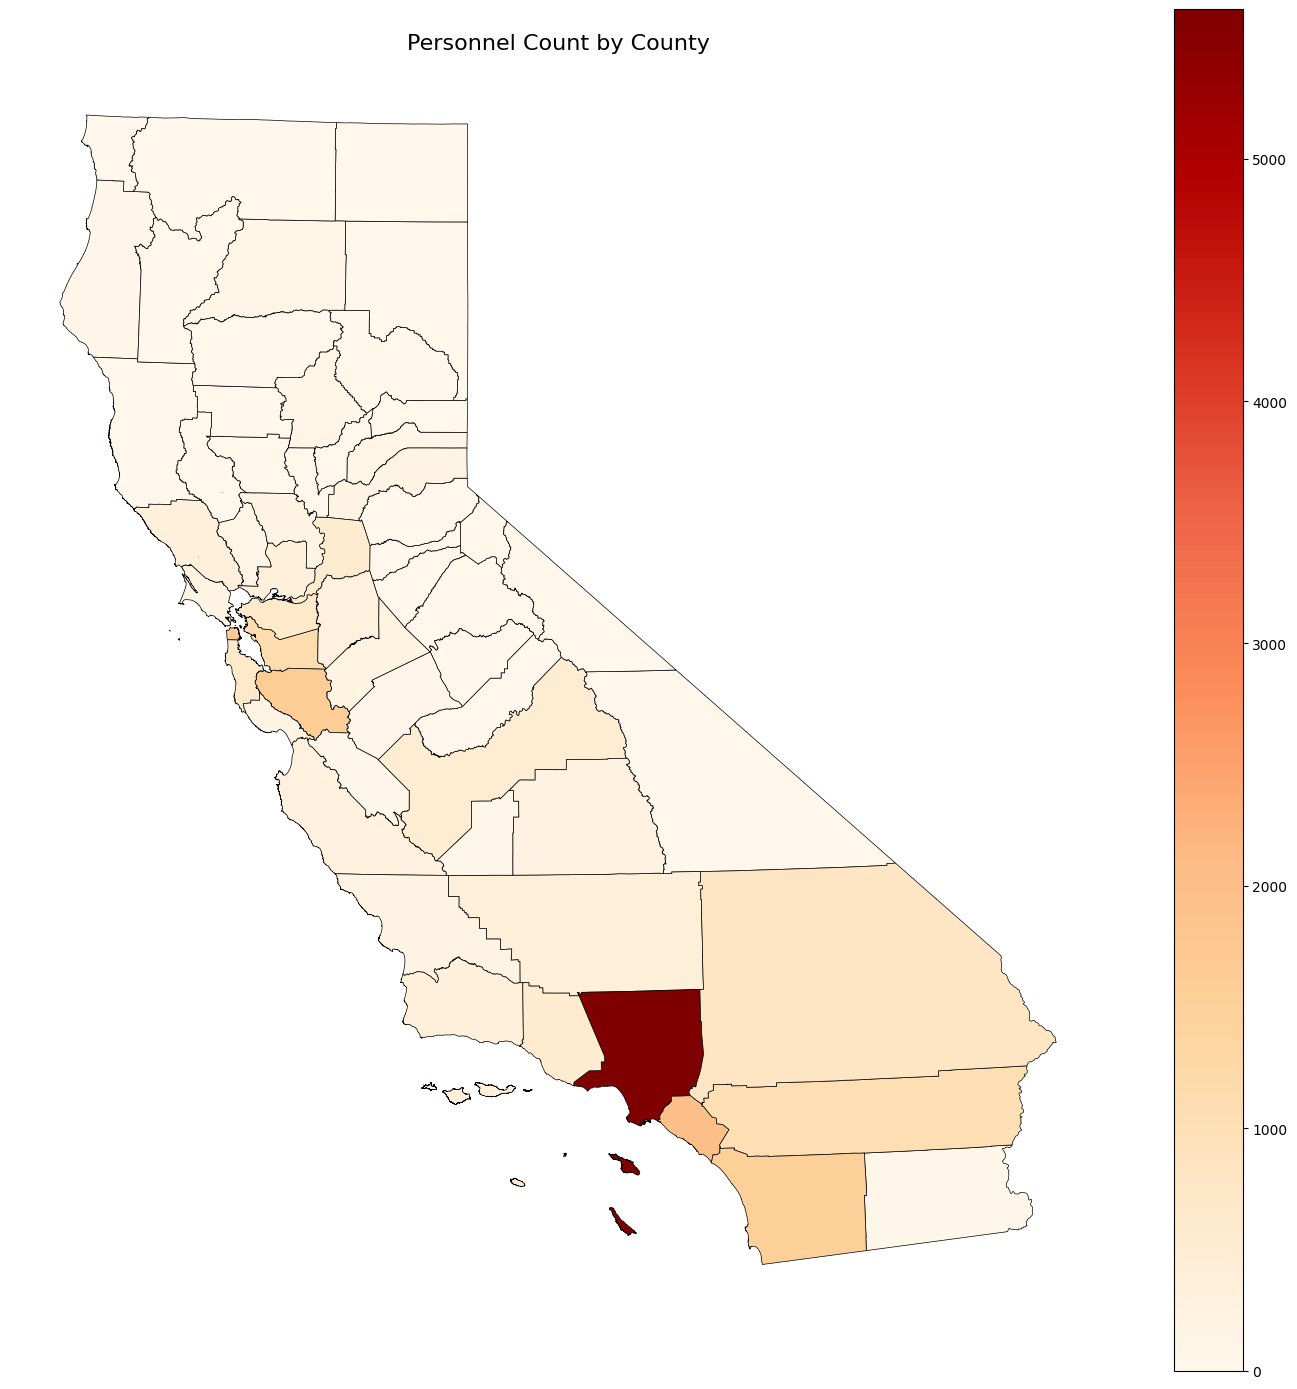

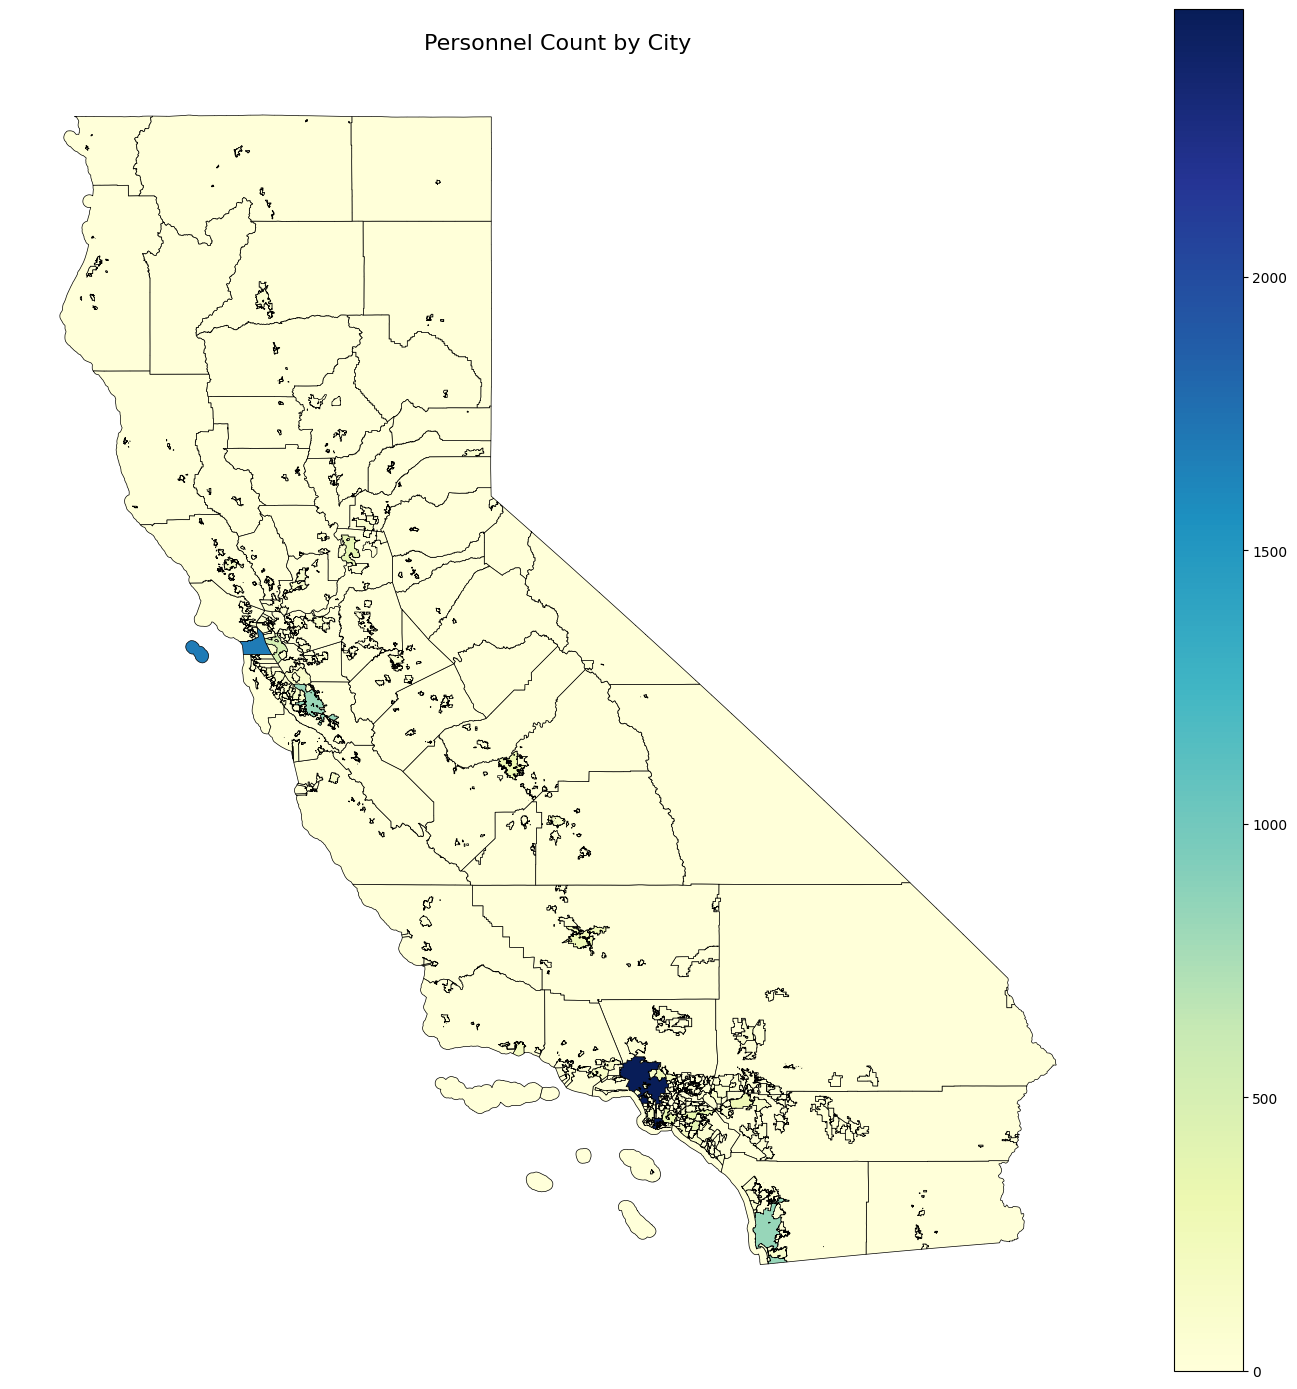

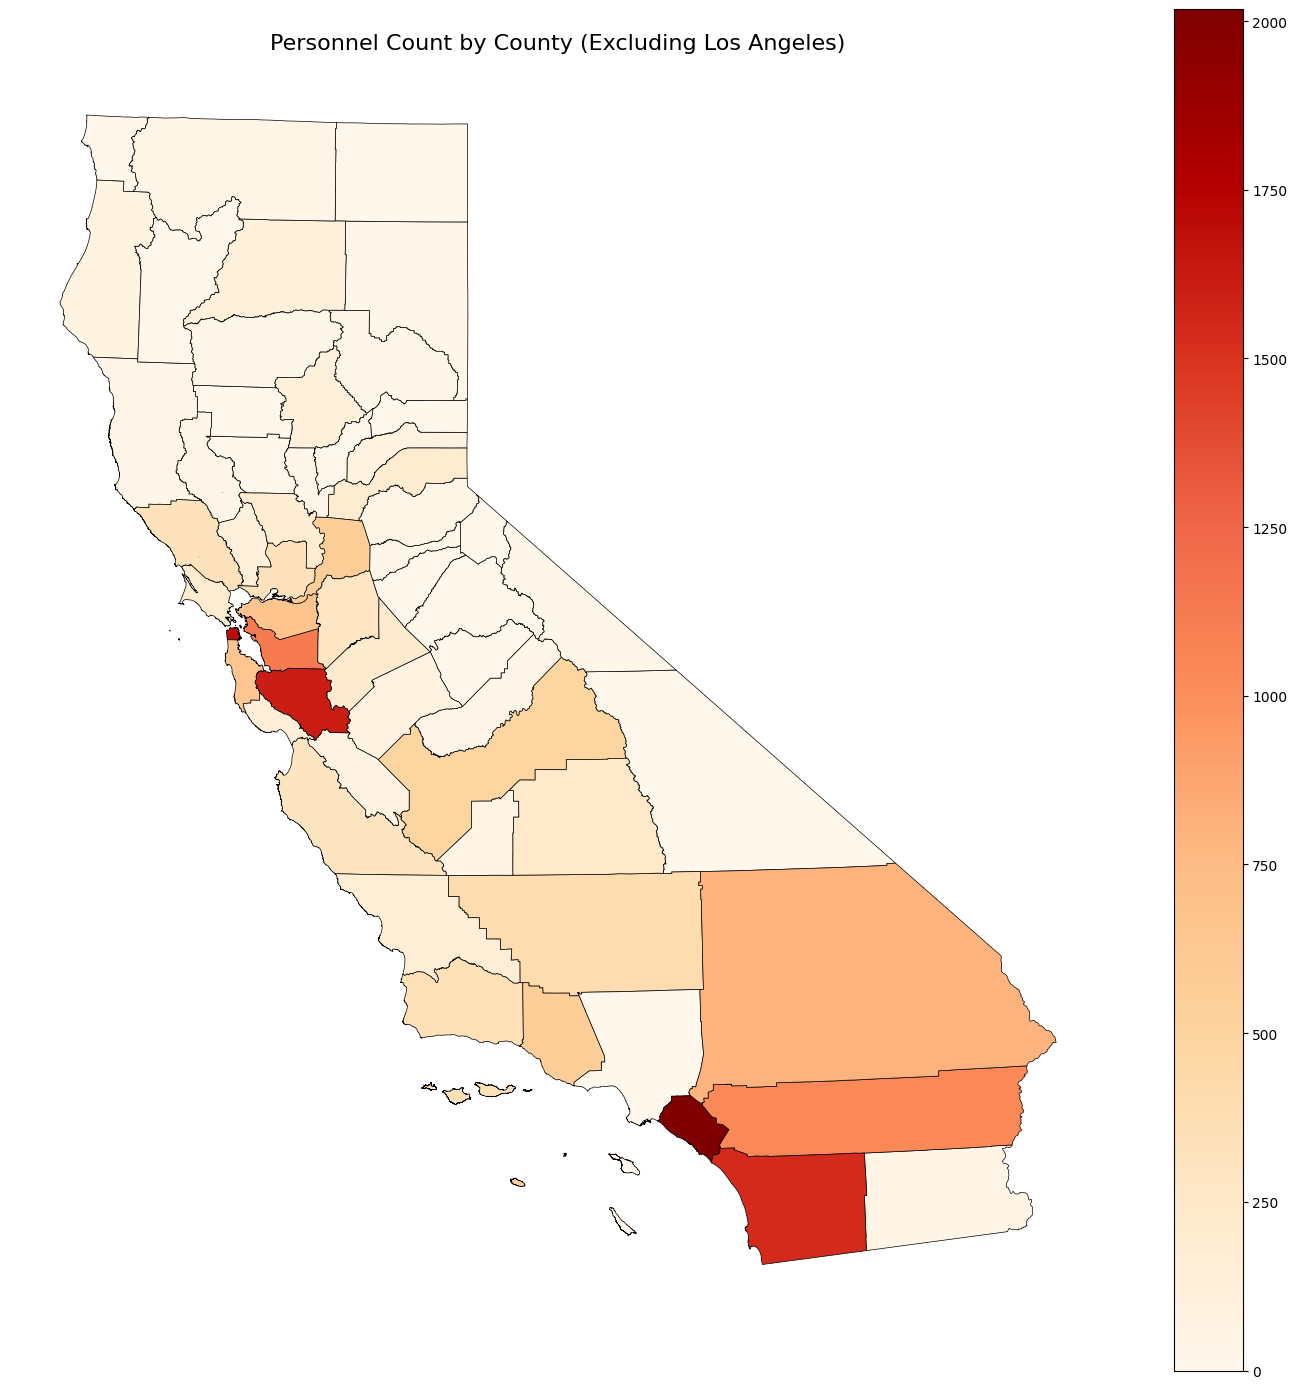

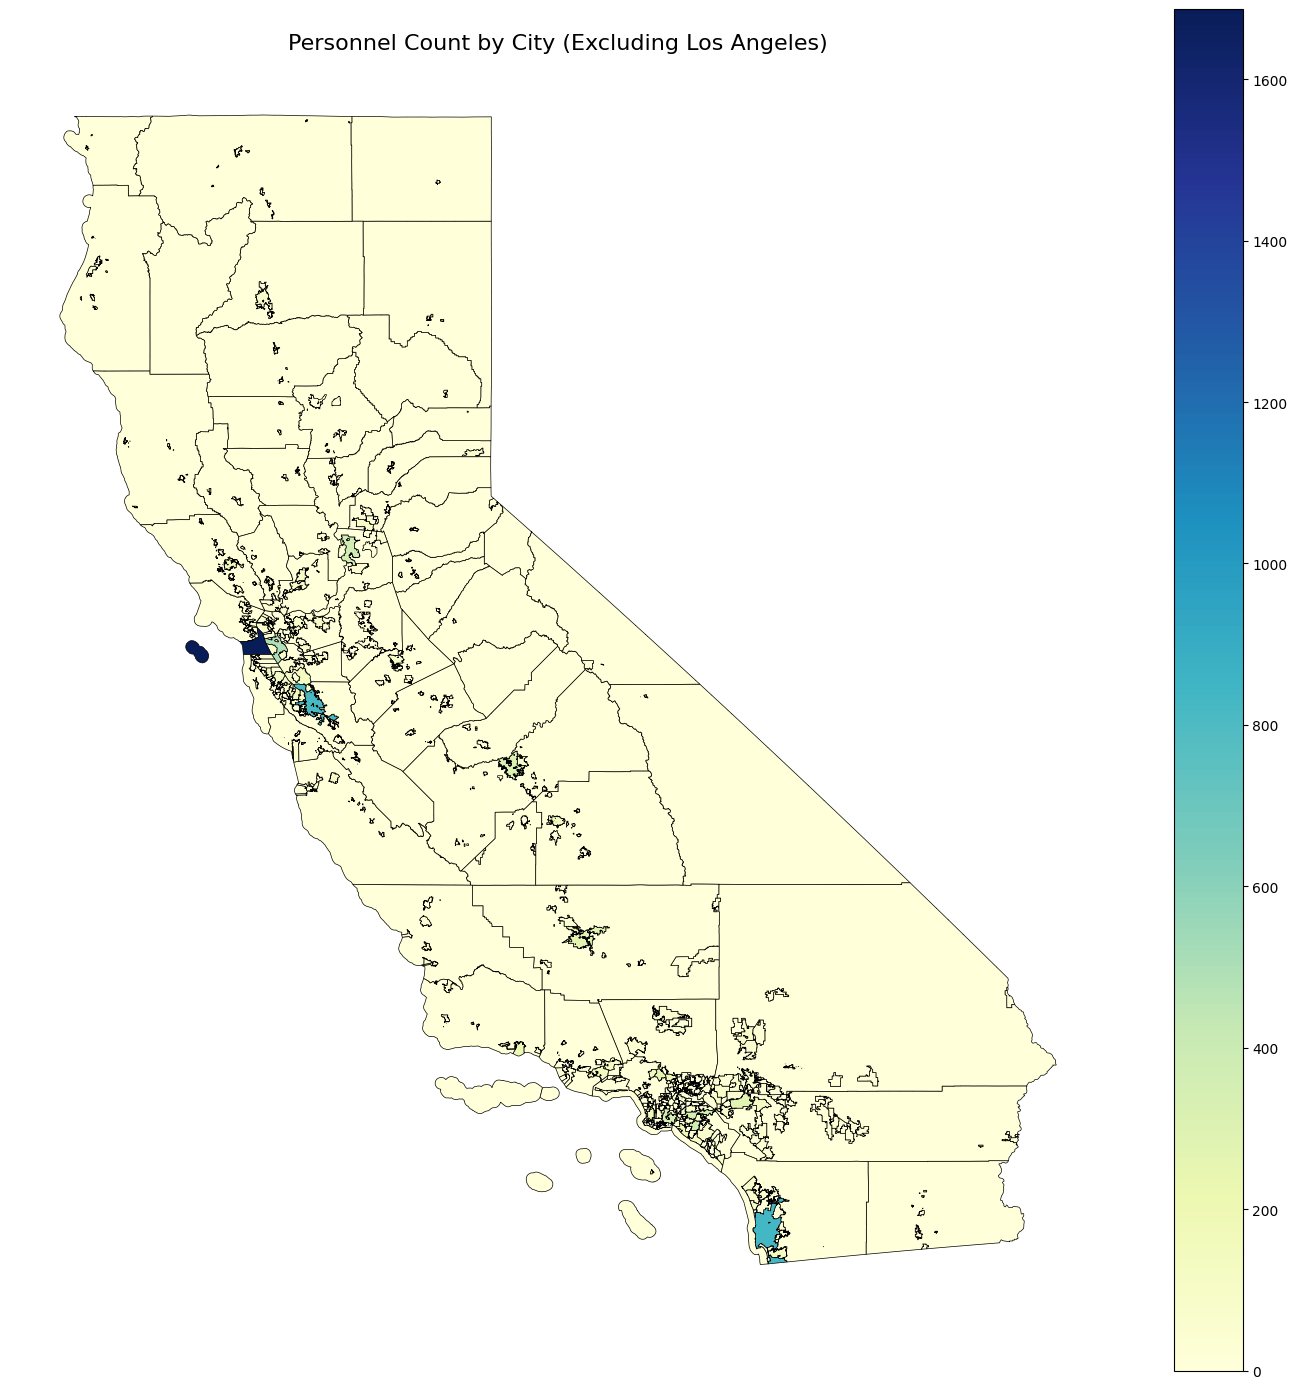

In [181]:
# Plot all maps

# County - All
plot_personnel_map(
    geo_county,
    column='personnel_count_county',
    title='Personnel Count by County',
    cmap='OrRd'
)

# City - All
plot_personnel_map(
    geo_city,
    column='personnel_count_city',
    title='Personnel Count by City',
    cmap='YlGnBu'
)

# County - Excluding Los Angeles
plot_personnel_map(
    geo_county_filtered,
    column='personnel_count_county',
    title = f"Personnel Count by County (Excluding {', '.join(excluded_counties)})",
    cmap='OrRd'
)

# City - Excluding Los Angeles
plot_personnel_map(
    geo_city_filtered,
    column='personnel_count_city',
    title = f"Personnel Count by City (Excluding {', '.join(excluded_cities)})",
    cmap='YlGnBu'
)



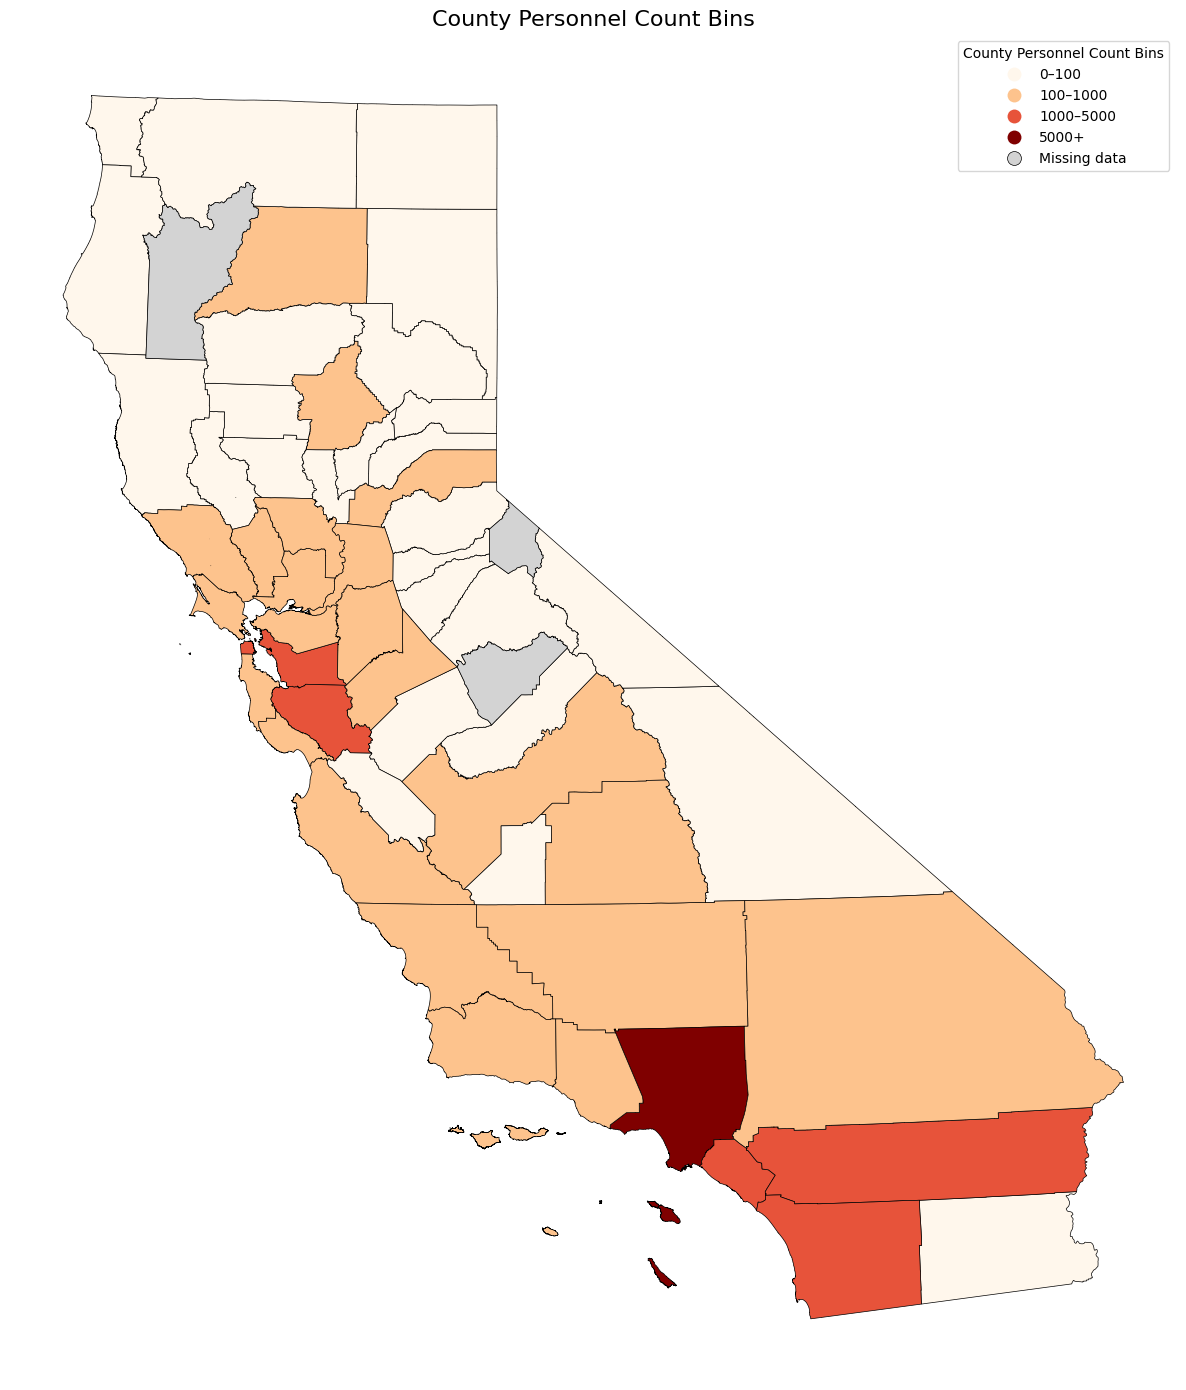

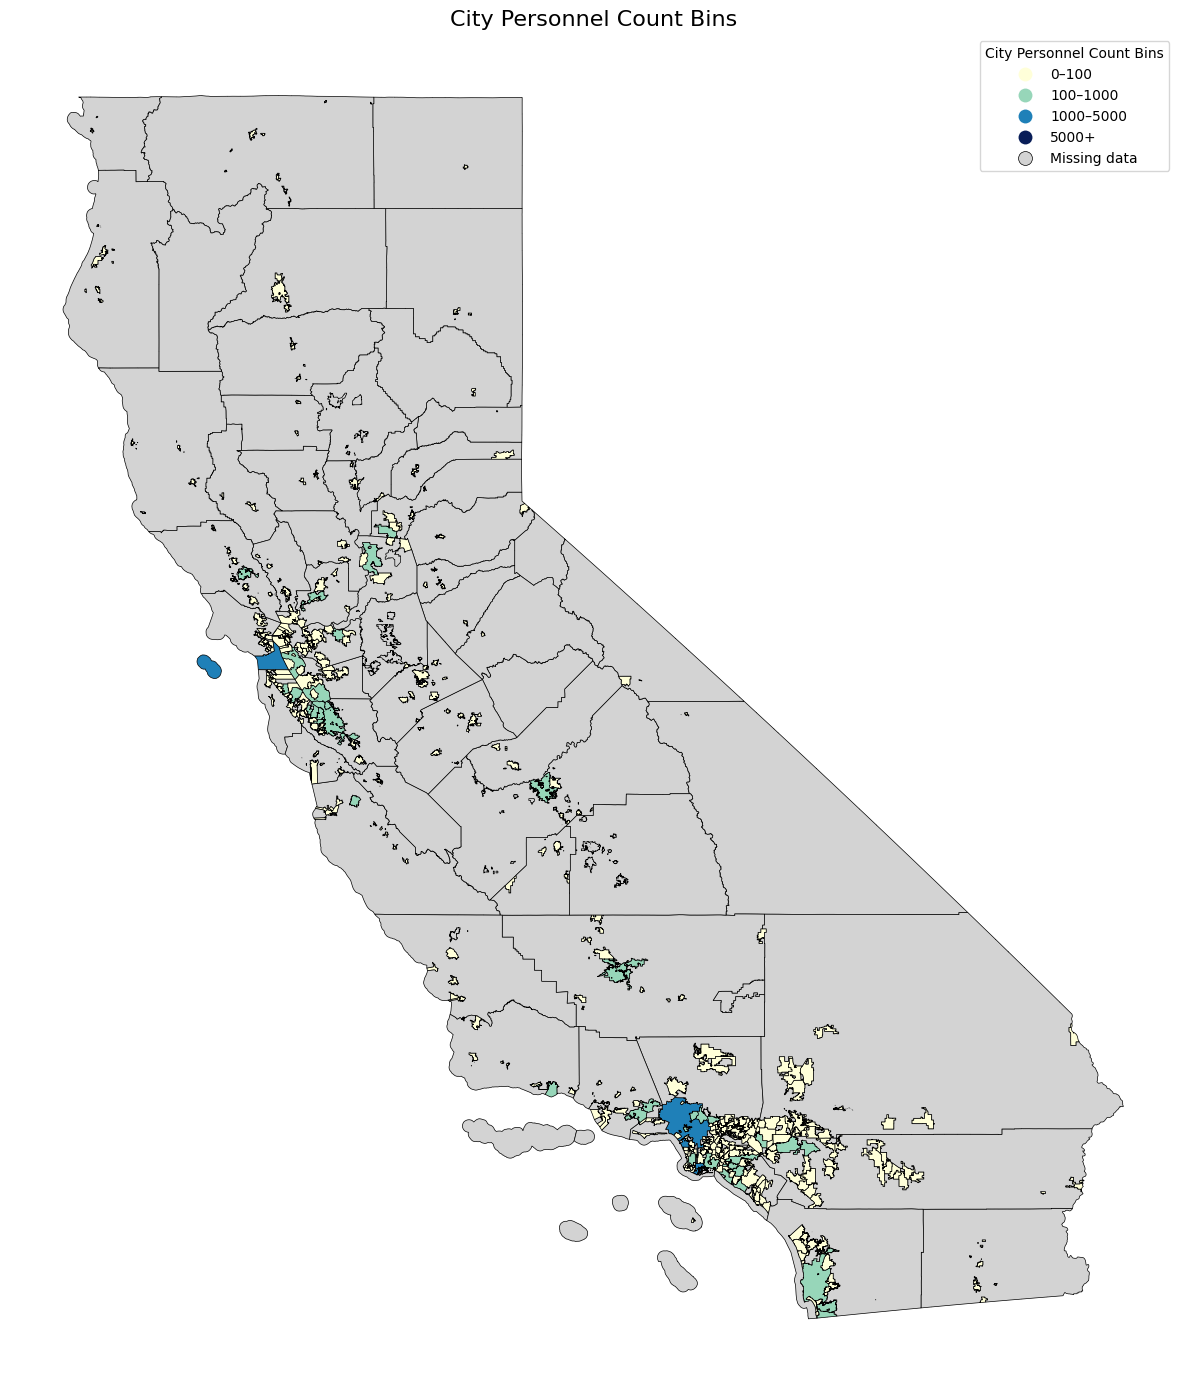

In [182]:
#  County Bins
plot_personnel_map(
    geo_county,
    column='county_personnel_bin',
    title='County Personnel Count Bins',
    cmap='OrRd'
)

#  City Bins
plot_personnel_map(
    geo_city,
    column='city_personnel_bin',
    title='City Personnel Count Bins',
    cmap='YlGnBu'
)

**<h3>General Statistics on Personnel Data Below**
* Dataframes: filtered_df, agg_city_counts, agg_county_counts, test_df

In [183]:
# Evaluating Model
y_test_true = test_df.apply(label_row, axis=1)  # True labels for test set
y_test_pred = test_df["predicted_label"]

In [184]:
# Classification Metrics
print("\nClassification Report:")
print(classification_report(y_test_true, y_test_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    225068
           1       0.96      0.96      0.96     15988

    accuracy                           0.99    241056
   macro avg       0.98      0.98      0.98    241056
weighted avg       0.99      0.99      0.99    241056



In [185]:
# F1-Score Discrete
f1 = f1_score(y_test_true, y_test_pred)
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.9603


In [186]:
# Confusion Matrix Raw
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_true, y_test_pred))


Confusion Matrix:
[[224475    593]
 [   674  15314]]


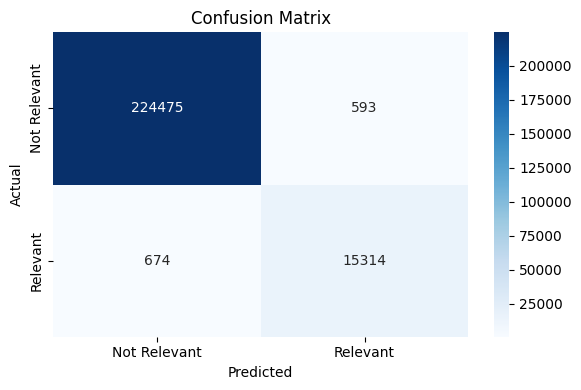

In [187]:
# Confusion Matrix Heatmap 
cm = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Relevant", "Relevant"], yticklabels=["Not Relevant", "Relevant"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

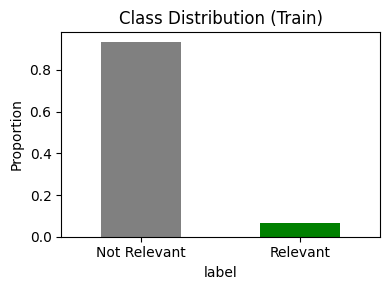

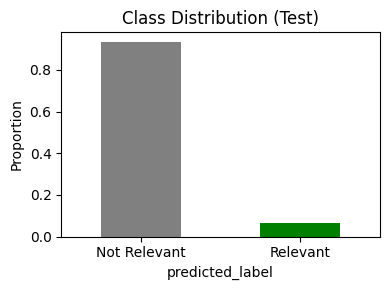

In [188]:
# Visualize the train imbalance in the data ~ Relevant vs. Non Relevant
plt.figure(figsize=(4, 3))
train_df["label"].value_counts(normalize=True).plot(kind="bar", color=["gray", "green"])
plt.title("Class Distribution (Train)")
plt.xticks(ticks=[0, 1], labels=["Not Relevant", "Relevant"], rotation=0)
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

# Visualize the test imbalance in the data ~ Relevant vs. Non Relevant
plt.figure(figsize=(4, 3))
test_df["predicted_label"].value_counts(normalize=True).plot(kind="bar", color=["gray", "green"])
plt.title("Class Distribution (Test)")
plt.xticks(ticks=[0, 1], labels=["Not Relevant", "Relevant"], rotation=0)
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

In [189]:
# Discrete proportions for each df
test_df["predicted_label"].value_counts(normalize=True)
#train_df["label"].value_counts(normalize=True)

predicted_label
0    0.934011
1    0.065989
Name: proportion, dtype: float64

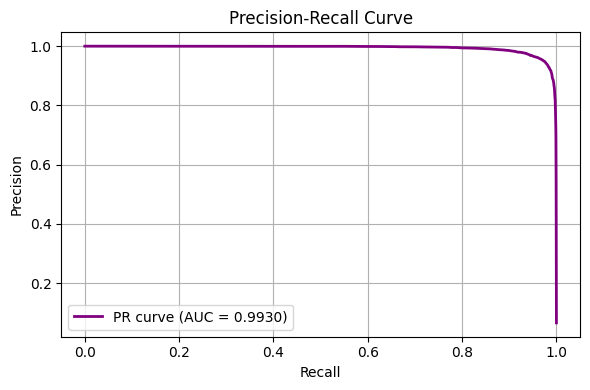

In [190]:
# Precision-Recall Curve
y_test_proba = model.predict_proba(test_df["combined_text"])[:, 1]  # Probabilities for class 1

precision, recall, thresholds = precision_recall_curve(y_test_true, y_test_proba)
pr_auc = average_precision_score(y_test_true, y_test_proba)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color='purple', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid()
plt.tight_layout()
plt.show()

In [191]:
# Check the Position and DepartmentOrSubdivision columns' stats here

#filtered_df.groupby('clean_city_name')['Position'].nunique().sort_values(ascending=False).head(10)
#filtered_df['DepartmentOrSubdivision'].value_counts().head(20)

In [192]:
# Cities Represented
print("Total Cities/Unincorporated Areas Represented: ", filtered_df['EmployerName'].dropna().nunique())
# Counties Represented
print("Total Counties Represented: ", filtered_df['EmployerCounty'].dropna().nunique())
# Total Positions
print("Total Positions:", filtered_df['Position'].value_counts().sum())
print("Total Unique Positions:", filtered_df['Position'].dropna().nunique())
# Departments / Subdivisions
print("Total Unique Depts:", filtered_df['DepartmentOrSubdivision'].dropna().nunique()
)

Total Cities/Unincorporated Areas Represented:  473
Total Counties Represented:  55
Total Positions: 22772
Total Unique Positions: 4253
Total Unique Depts: 599


In [193]:
# Most workers per city
city_counts = filtered_df['clean_city_name'].value_counts()
print("Top 5 Cities by Worker Count:\n", city_counts.head(5))

# Least workers (but drop NaNs first)
print("\nBottom 5 Cities by Worker Count:\n", city_counts[city_counts > 0].tail(5))
print("\nNAs:\n", city_counts.isna().sum())


Top 5 Cities by Worker Count:
 clean_city_name
Los Angeles      2490
San Francisco    1687
San Diego         834
San Jose          818
Oakland           499
Name: count, dtype: int64

Bottom 5 Cities by Worker Count:
 clean_city_name
Gridley         1
Etna            1
Del Rey Oaks    1
Trinidad        1
Westmorland     1
Name: count, dtype: int64

NAs:
 0


In [194]:
# Most workers per county
county_counts = filtered_df['clean_county_name'].value_counts()
print("Top 10 Counties by Worker Count:\n", county_counts.head(10))

# Least workers
print("\nBottom 10 Counties by Worker Count:\n", county_counts[county_counts > 0].tail(10))
print("\nNAs:\n", county_counts.isna().sum())


Top 10 Counties by Worker Count:
 clean_county_name
Los Angeles       5618
Orange            2018
San Francisco     1687
Santa Clara       1604
San Diego         1544
Alameda           1127
Riverside         1035
San Bernardino     802
Contra Costa       666
San Mateo          641
Name: count, dtype: int64

Bottom 10 Counties by Worker Count:
 clean_county_name
Plumas       16
Yuba         15
Glenn         9
Tuolumne      9
Del Norte     9
Colusa        8
Calaveras     8
Modoc         4
Inyo          2
Sierra        2
Name: count, dtype: int64

NAs:
 0


In [195]:
g = 10  # Change as needed

# Cities with < g positions
cities_under_g = city_counts[city_counts < g]
print(f"\nNumber of cities with fewer than {g} positions: {len(cities_under_g)}")
print(cities_under_g.head(10))



Number of cities with fewer than 10 positions: 115
clean_city_name
Kingsburg            9
Carmel-By-The-Sea    9
La Palma             9
Newman               9
Wheatland            9
Atwater              9
Sonora               9
Commerce             9
Woodside             9
Lynwood              9
Name: count, dtype: int64


In [196]:
b = 25 # Change as needed

# Counties with < b positions
counties_under_b = county_counts[county_counts < b]
print(f"\nNumber of counties with fewer than {b} positions: {len(counties_under_b)}")
print(counties_under_b.head(10))


Number of counties with fewer than 25 positions: 16
clean_county_name
Mendocino    24
Lake         24
Amador       21
Mono         21
Tehama       18
Lassen       17
Plumas       16
Yuba         15
Glenn         9
Tuolumne      9
Name: count, dtype: int64


In [197]:
# Missing city name
missing_city = filtered_df['clean_city_name'].isna().sum()
print(f"Rows with missing city name: {missing_city}")

# Missing county name
missing_county = filtered_df['clean_county_name'].isna().sum()
print(f"Rows with missing county name: {missing_county}")

# Optionally: View rows
#filtered_df[filtered_df['clean_city_name'].isna() | filtered_df['clean_county_name'].isna()]


Rows with missing city name: 0
Rows with missing county name: 0


In [198]:
# View Distributions
print("City Personnel Bins Distribution")
print(agg_city_counts['city_personnel_bin'].value_counts().sort_index())

print("County Personnel Bin Distribution")
print(agg_county_counts['county_personnel_bin'].value_counts().sort_index())

City Personnel Bins Distribution
city_personnel_bin
0–100        433
100–1000      38
1000–5000      2
5000+          0
Name: count, dtype: int64
County Personnel Bin Distribution
county_personnel_bin
0–100        26
100–1000     22
1000–5000     6
5000+         1
Name: count, dtype: int64
